#### Model Checkpointing or Early Stopping - AlexNet

## Project Overview

This project investigates the use of **early stopping** for improving deep learning models used in image classification tasks. The experiment focuses on the classification of **sugarcane leaf images** to identify different plant diseases.

The dataset used in this study is already well-structured into class-specific folders; therefore, no additional restructuring is required. The primary focus of the project is to compare **training strategies**, specifically **model checkpointing** and **early stopping**, and evaluate their impact on model performance and generalization.

The objective is to assess how early stopping influences **model generalization**, training efficiency, and overall classification performance.

---

### Dataset

The dataset used in this project is the **Sugarcane Plant Diseases Dataset**, available on Kaggle:

https://www.kaggle.com/datasets/akilesh253/sugarcane-plant-diseases-dataset

The dataset consists of **19,926 images** of sugarcane leaves, categorized into different disease conditions as well as healthy samples.

### Dataset Characteristics

* Images of sugarcane leaves captured under varying conditions
* JPG image format
* Pre-organized into class-specific folders
* Augmented dataset with transformations such as rotation, flipping, zooming, resizing, and cropping
* Suitable for supervised deep learning classification tasks

### Classes

The dataset contains six classes representing different conditions of sugarcane leaves:

1. **Bacterial Blight Disease**
2. **Healthy Leaves**
3. **Mosaic Disease**
4. **Red Rot Disease**
5. **Rust Disease**
6. **Yellow Disease**

These classes include both **healthy samples** and **multiple disease types**, enabling the development of robust classification models for plant disease detection.

---

### Data Augmentation (Dataset Level)

The dataset has already been augmented using the following techniques:

* Random rotation (up to 90°)
* Horizontal and vertical flipping
* Zooming (0.8× to 1.2×)
* Resizing to a consistent resolution
* Cropping (central crop)

These augmentation strategies increase dataset diversity and help improve model generalization.

---

### Model

The deep learning model used in this experiment is **AlexNet**, implemented using **TorchVision**.

AlexNet is a convolutional neural network architecture designed for image classification and serves as a strong baseline for computer vision tasks.

In this study, the final layer of AlexNet is modified to accommodate **six output classes**, corresponding to the sugarcane disease categories.

---

### Objective

The main objective of this project is to investigate:

1. The effectiveness of **early stopping** in preventing overfitting
2. The impact of different **training strategies** (checkpointing vs early stopping)
3. The ability of AlexNet to classify **sugarcane leaf diseases**
4. The generalization performance of the model on unseen data

---

### Dataset Citation

AKILESH_S (Dataset Author)

*Sugarcane Plant Diseases Dataset.*

Kaggle, updated 1 year ago.

> https://www.kaggle.com/datasets/akilesh253/sugarcane-plant-diseases-dataset


### Imports

In this section, all required libraries and dependencies used throughout the notebook are imported. These packages support data handling, preprocessing, model development, training, and evaluation.

In [1]:
import torch
import random
import os
import time
import torchvision
import copy
import json
import shutil

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch.nn import functional as F
from pigmenta import PALETTES
from torchvision import datasets, transforms
from torch.utils import data
from PIL import Image
from sklearn.metrics import  classification_report
from helperfns.tables import tabulate_data
from helperfns.visualization import plot_complicated_confusion_matrix, plot_simple_confusion_matrix
from helperfns.utils import hms_string
from helperfns import visualization

import seaborn as sns
import pathlib
import matplotlib as mpl
import statistics as stat

torch.__version__

'2.9.0+cu126'

### Random Seed Initialization

Reproducibility is an important aspect of machine learning experiments.  
To ensure consistent results across different runs, a fixed random seed is defined and applied throughout this notebook.

Setting a seed controls sources of randomness in libraries such as **PyTorch**, **NumPy**, and Python's built-in random module, helping to ensure that model training, data shuffling, and other stochastic processes behave deterministically.

The following code cell initializes the `SEED` used in the experiments.

In [2]:
SEED = 23

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

### Device Configuration

Deep learning models can benefit significantly from hardware acceleration.  
In this section, the computational device is configured to use a **GPU** if one is available. Utilizing a GPU allows for faster matrix operations and parallel computation, which can substantially reduce model training time.

The following code cell selects and initializes the device that will be used during training and evaluation.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Dataset

The dataset used in this study is obtained from **Kaggle** and integrated into the notebook environment for model development and evaluation.

Dataset source:
https://www.kaggle.com/datasets/akilesh253/sugarcane-plant-diseases-dataset

This dataset consists of **images of sugarcane leaves** used for the detection and classification of **plant diseases**. The images are organized into class-specific folders, making them suitable for deep learning-based image classification tasks.

### Dataset Characteristics

* Sugarcane leaf images
* JPG image format
* Pre-arranged into labeled folders
* Augmented dataset (rotation, flipping, zooming, resizing, cropping)
* Suitable for supervised learning tasks

### Classes

The dataset contains six classes representing different conditions of sugarcane leaves:

1. `Bacterial Blight Disease`
2. `Healthy Leaves`
3. `Mosaic Disease`
4. `Red Rot Disease`
5. `Rust Disease`
6. `Yellow Disease`

These classes represent both **healthy samples** and **various plant diseases**, enabling the development of models capable of identifying and distinguishing between multiple disease conditions.

This dataset enables the development and evaluation of deep learning models for **automated sugarcane disease classification**, supporting early detection and improved agricultural decision-making.


In [5]:
with open("C://Users//crisp//Downloads//kaggle.json", 'r') as reader:
  keys = json.loads(reader.read())
  os.environ['KAGGLE_USERNAME'] = keys['username']
  os.environ['KAGGLE_KEY'] = keys['key']

!kaggle datasets download akilesh253/sugarcane-plant-diseases-dataset --unzip -q

Dataset URL: https://www.kaggle.com/datasets/akilesh253/sugarcane-plant-diseases-dataset
License(s): Community Data License Agreement - Sharing - Version 1.0


### Dataset Channel Statistics

In the following code cell, we compute the **mean** and **standard deviation** for each color channel (**Red, Green, and Blue**) across the entire dataset.

These statistics are important for **data normalization**, which helps stabilize training and improve the convergence of deep learning models. By calculating the channel-wise mean and standard deviation of the dataset, we can normalize the images so that each channel has a consistent scale during model training.

In [6]:
data_path = "Sugarcane_leafs"
image_size = (224, 224)
train_data = datasets.ImageFolder(
    root=data_path,
    transform= transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
      ])
    )

means = torch.zeros(3)
stds = torch.zeros(3)

for img, label in train_data:
  means += torch.mean(img, dim = (1,2))
  stds += torch.std(img, dim = (1,2))

means /= len(train_data)
stds /= len(train_data)

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')

Calculated means: tensor([0.4577, 0.4770, 0.3860])
Calculated stds: tensor([0.1707, 0.1720, 0.1763])


### Image Transformations

---

### `image_transforms` - Training and Evaluation Pipeline for Sugarcane Disease Classification

To enhance model performance and generalization, a series of image transformations are applied during the preprocessing stage. These transformations standardize input images and introduce controlled variability during training, which is essential for robust plant disease classification.

#### Training Transformations

The following transformations are applied to the **training dataset**:

1. `Resize((224, 224))`
   – Ensures all images match the input size required by AlexNet

2. `RandomRotation(5)`
   – Introduces slight rotational variation to improve robustness to orientation changes

3. `RandomHorizontalFlip(0.5)`
   – Randomly flips images horizontally with a probability of 0.5

4. `RandomCrop(224, padding=10)`
   – Applies random cropping with padding to simulate positional and scale variations

5. `ToTensor()`
   – Converts images into PyTorch tensors

6. `Normalize(mean=computed_means, std=computed_stds)`
   – Normalizes pixel values using dataset-specific statistics

#### Validation and Test Transformations

For the **validation and test datasets**, only deterministic preprocessing steps are applied to ensure consistent and unbiased evaluation:

1. `Resize((224, 224))`
2. `ToTensor()`
3. `Normalize(mean=computed_means, std=computed_stds)`

#### Purpose

These transformations help to:

* Improve **model generalization** by introducing variability during training
* Enhance robustness to **lighting, orientation, and positional differences** in leaf images
* Maintain **evaluation consistency** by avoiding randomness in validation/testing
* Ensure compatibility with **AlexNet input requirements (224×224)**
* Standardize image distributions through normalization

Overall, this preprocessing pipeline supports effective and reliable training of the sugarcane disease classification model.


In [7]:
image_transforms = {
    "train": transforms.Compose([
              transforms.Resize((224, 224)),
              transforms.RandomRotation(5),
              transforms.RandomHorizontalFlip(.5),
              transforms.RandomCrop(224, padding=2),
              transforms.ToTensor(),
              transforms.Normalize(mean=means, std=stds, inplace=False)
          ]),
    "valid": transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          transforms.Normalize(mean = means,
                            std = stds)
        ]),
    "test": transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          transforms.Normalize(mean = means,
                            std = stds)
    ])
}

### Dataset Creation

In this section, the dataset is created using PyTorch’s `ImageFolder` class, which automatically assigns labels based on the directory structure of the dataset.

The dataset is organized into class-specific folders representing the different **sugarcane leaf conditions** (healthy and diseased). This structure enables `ImageFolder` to correctly map each image to its corresponding class label.

Two datasets are defined:

* **Training dataset**
  Applies data augmentation and preprocessing transformations to improve model generalization

* **Validation/Test dataset**
  Applies only standard preprocessing transformations to ensure consistent and unbiased evaluation

After creating the datasets, the **class names** provided by `ImageFolder` are inspected to verify that the dataset has been loaded correctly and that all classes are properly recognized.

This step ensures that the data pipeline is correctly configured before proceeding to model training and evaluation.


In [8]:
dataset = datasets.ImageFolder(data_path, transform = image_transforms['train'])
class_names = dataset.classes
class_names

['BacterialBlights', 'Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']

In [9]:
dataset.class_to_idx

{'BacterialBlights': 0,
 'Healthy': 1,
 'Mosaic': 2,
 'RedRot': 3,
 'Rust': 4,
 'Yellow': 5}

### Dataset Splitting

To prepare the dataset for training and evaluation, the images are divided into **training**, **validation**, and **test** subsets using a two-step random splitting approach.

First, the entire dataset of sugarcane leaf images is split into **training** and **test** sets:

* **20% of the data** is allocated to the **test set**
* The remaining **80%** is retained for training and validation

Next, the training portion (80%) is further divided into:

* **Training set** (80% of the remaining data)
* **Validation set** (20% of the remaining data)

This results in an approximate overall distribution of:

* **Training set** ≈ 64%
* **Validation set** ≈ 16%
* **Test set** ≈ 20%

The splitting is performed using PyTorch’s `random_split` function, which randomly partitions the dataset into non-overlapping subsets.

#### Important Note

This approach performs **random splitting without explicit stratification**, meaning class distributions are approximately preserved but not strictly guaranteed across all subsets. However, given the relatively balanced nature of the dataset, this approach remains suitable for this study.

#### Purpose

This splitting strategy ensures:

* Availability of **unseen test data** for final model evaluation
* Use of a **validation set** for monitoring training performance and applying early stopping
* Efficient utilization of data for **learning robust disease classification patterns**

Overall, this setup provides a practical and widely adopted framework for training and evaluating deep learning models for **sugarcane disease classification**.


In [10]:
VALID_RATIO = 0.2
TEST_RATIO = 0.2

# Split into train + test
n_test_examples = int(len(dataset) * TEST_RATIO)
n_train_examples = len(dataset) - n_test_examples

train_data, test_data = data.random_split(dataset,
                                          [n_train_examples, n_test_examples])
n_valid_examples = int(len(train_data) * VALID_RATIO)
n_train_examples = len(train_data) - n_valid_examples
train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])


### Preventing Data Leakage

Since the datasets were initially created using the **training transformation pipeline**, the validation and test subsets will inherit the same transformations by default.

To prevent **data leakage**, the transformations for the **validation** and **test** sets will be overridden with their respective preprocessing pipelines. These pipelines exclude training-specific augmentations and only include deterministic preprocessing steps.

This ensures that the validation and test data remain **unseen and unbiased**, allowing for a fair and reliable evaluation of the model's performance.

In [11]:
valid_data = copy.deepcopy(valid_data)
test_data = copy.deepcopy(test_data)

valid_data.dataset.transform = image_transforms['valid']
test_data.dataset.transform = image_transforms['test']

### Dataset Distribution

In the following code cell, we inspect the distribution of samples across the **training**, **validation**, and **test** sets. This verification step ensures that the dataset was split correctly and that the class distribution remains consistent across all subsets.

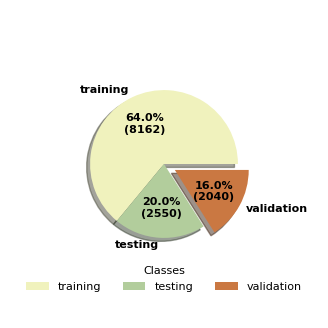

In [12]:
examples	= dict([
    ("training", len(train_data)),
    ("testing", len(test_data)),
    ("validation", len(valid_data))
])
plt.figure(figsize=(4, 4))
def fmt(x, total):
    return '{:.1f}%\n({:.0f})'.format(x, total*x/100)

plt.pie(
    examples.values(), labels=examples.keys(), explode= [.0, .0, .1],
    pctdistance=0.6, shadow=True, autopct=lambda x: fmt(x, len(train_data)),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    radius=.6, colors=PALETTES.wedding[12:],
    
)
plt.legend(
    fontsize=8, labels=list(examples.keys()), loc="upper center",
    bbox_to_anchor=(0.5, 0.2),
    title="Classes", ncol=3, frameon=False, title_fontsize=8
)
plt.show()

### Data Iterators

Data iterators are used to load and process the dataset in mini-batches during training and evaluation. Since the model contains a large number of parameters and operates on relatively large input images, training can be computationally expensive. To balance computational efficiency and training stability, a **batch size of 128** is used.

In [13]:
BATCH_SIZE = 128

train_iterator = data.DataLoader(
    train_data, shuffle=True, batch_size= BATCH_SIZE
)
valid_iterator = data.DataLoader(
    valid_data, batch_size= BATCH_SIZE
)
test_iterator = data.DataLoader(
    test_data,  batch_size= BATCH_SIZE
)


### Visualizing Sample Images

Before training the model, we visualize a selection of images from the dataset.  
This step helps confirm that the preprocessing pipeline has been applied correctly and provides a better understanding of the visual features present in the data.

In [14]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

In the following code cell we are going to define a function that will plot the normalised images from our datasets.

In [15]:
def plot_images(images, labels, normalize = True):
  n_images = len(images)
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (10, 10))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image = images[i]
    if normalize:
        image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy())
    ax.set_title(class_names[labels[i]], color = "g" if labels[i] == 1 else "r", fontsize=8)
    ax.axis('off')

### Visualizing Sample Images

We begin by visualizing a few sample images from the dataset after preprocessing. This step provides an initial understanding of the **sugarcane leaf images** and allows verification that the data has been correctly loaded, transformed, and labeled.

Visual inspection is important to ensure that:

* The images are properly **resized and normalized**
* Class labels correctly correspond to the **leaf conditions** (healthy and diseased)
* The visual characteristics of different diseases are distinguishable
* The overall data quality is suitable for model training

This step serves as a sanity check before proceeding to model training and evaluation, helping to identify any potential issues in the data pipeline early in the process.


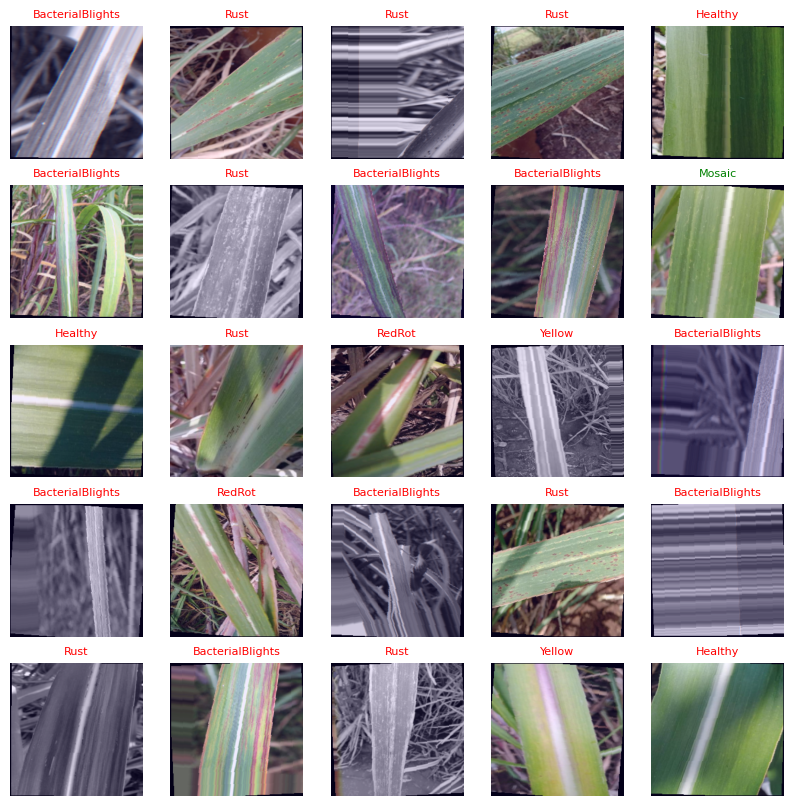

In [16]:
N_IMAGES = 25
images, labels = zip(*[(image, label) for image, label in
                           [train_data[i] for i in range(N_IMAGES)]])
plot_images(images, labels)

### AlexNet

In this notebook, we implement a modified version of **AlexNet**, a deep convolutional neural network (CNN) architecture designed for image classification. AlexNet was originally introduced for the *ImageNet Large Scale Visual Recognition Challenge (ILSVRC)* and gained prominence after winning the competition in 2012, significantly outperforming competing models and accelerating the adoption of deep learning in computer vision.

In this study, AlexNet is adapted for **multi-class classification of sugarcane leaf images** to identify different **plant diseases and healthy conditions**. The original architecture is modified by adjusting the final fully connected layer to match the **six output classes** in the dataset.

These classes include:

* Bacterial Blight Disease
* Healthy Leaves
* Mosaic Disease
* Red Rot Disease
* Rust Disease
* Yellow Disease

The model processes input images resized to **224 x 224**, which aligns with the input requirements of AlexNet.

The following code cell defines the modified **AlexNet architecture** used for training and evaluation in this study. The implementation is adapted from the following reference:

https://github.com/CrispenGari/pytorch-python/blob/main/03_Torch_Vision/03_Image_Classification/03_AlexNet.ipynb


In [17]:
class AlexNet(nn.Module):
  def __init__(self, output_dim):
    super(AlexNet, self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(3, 64, 3, 2, 1), # in_channels, out_channels, kernel_size, stride, padding
        nn.MaxPool2d(2),
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 192, 3, padding=1),
        nn.MaxPool2d(2),
        nn.ReLU(inplace=True),
        nn.Conv2d(192, 384, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(384, 256, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 256, 3, padding=1),
        nn.MaxPool2d(2),
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 128, 3, padding=1),
        nn.MaxPool2d(2),
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 64, 3, padding=1),
        nn.MaxPool2d(2),
        nn.ReLU(inplace=True),
    )

    self.classifier = nn.Sequential(
        nn.Dropout(.5),
        nn.Linear(64 * 3 * 3, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, output_dim),
    )

  def forward(self, x):
    x = self.features(x)
    h = x.view(x.shape[0], -1)
    x = self.classifier(h)
    return x, h

### Model Initialization

In this section, the models are initialized and transferred to the selected computational **device** (CPU or GPU). Utilizing a GPU, when available, significantly improves the efficiency of both training and inference.

Two separate instances of the AlexNet model are created to evaluate different training strategies:

1. **Checkpointing Model**
   – This model is trained using a **model checkpointing strategy**, where the best-performing model (based on validation loss) is saved during training.

2. **Early Stopping Model**
   – This model is trained using an **early stopping strategy**, where training is halted once the validation performance stops improving.

   > Both models share the same architecture and dataset but differ in their training strategy. This setup allows for a direct comparison of how each technique affects model performance and generalization.


In [64]:
OUTPUT_DIM = 1 if len(class_names) == 2 else len(class_names)
checkpoint_model = AlexNet(OUTPUT_DIM).to(device)
earlystop_model = AlexNet(OUTPUT_DIM).to(device)
earlystop_model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): ReLU(inplace=True)
    (13): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): ReLU(inplace=Tru

### Counting Model Parameters

In the following code cell, the number of **trainable parameters** in each model is calculated.

Both models are expected to have the **same number of parameters**, as they share an identical AlexNet architecture. The only difference between the models lies in the **training strategy**, where:

* One model is trained using a **model checkpointing strategy**
* The other model is trained using an **early stopping strategy**

This step verifies that any differences in performance are due to the **training approach** rather than differences in model complexity.

In [65]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return total_params, trainable_params

total_params_1, trainable_params_1 = count_params(checkpoint_model)
total_params_2, trainable_params_2 = count_params(earlystop_model)

tabulate_data(["","Total Parameters", "Trainable Parameteres"],
           [["checkpoint_model", f'{total_params_1:,}', f'{trainable_params_1:,}'],
            ["earlystop_model",f'{total_params_2:,}',  f'{trainable_params_2:,}']],
           "MODEL PARAMETERS")

MODEL PARAMETERS
+------------------+------------------+-----------------------+
|                  | Total Parameters | Trainable Parameteres |
+------------------+------------------+-----------------------+
| checkpoint_model |       21,789,702 |            21,789,702 |
| earlystop_model  |       21,789,702 |            21,789,702 |
+------------------+------------------+-----------------------+


### Training Configuration

In this section, the **optimizers** and **loss functions** used for training the models are defined.

The **Adam optimizer** is employed to update the model weights during training due to its adaptive learning rate capabilities and efficient convergence properties. Default parameters are used for optimization.

The **CrossEntropyLoss** function is selected as the training criterion, as the task is formulated as a **multi-class classification problem** involving five diabetic retinopathy severity classes.

Both models (checkpointing and early stopping) use the same optimizer and loss function to ensure a **fair and consistent comparison**. This guarantees that any observed differences in performance are attributed solely to the **training strategy** rather than differences in optimization settings.

In [66]:
optimizers = {
    'checkpoint': torch.optim.Adam(checkpoint_model.parameters()),
    'earlystop': torch.optim.Adam(earlystop_model.parameters()),
}

criterions = {
    'checkpoint': nn.CrossEntropyLoss().to(device),
    'earlystop': nn.CrossEntropyLoss().to(device),
}

### Categorical Accuracy Function

In this section, the `categorical_accuracy` function is implemented to evaluate the classification performance of the model.

The function computes accuracy by comparing the **predicted class labels** with the **true labels** for each batch of data. The predictions are obtained by selecting the class with the highest predicted probability.

The resulting value represents the **proportion of correctly classified samples**, making it a suitable performance metric for this multi-class classification task.

This metric is used during both **training** and **validation** phases to monitor model performance and assess its ability to generalize to unseen data.


In [67]:
def categorical_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float()/ y.shape[0]
  return acc

### Training and Evaluation Functions

In this section, we define two core functions used during the training process: **`train`** and **`evaluate`**.

---

### 1. `train`

The `train` function performs one epoch of model training and updates the model parameters. The following steps are executed:

- The model is set to **training mode** using `model.train()`.
- We iterate over the data iterator and move both the **input images** and **labels** to the selected computational **device**.
- The gradients are reset at the start of each iteration using `optimizer.zero_grad()`.
- The model performs a **forward pass** to generate predictions.
- The **loss** and **categorical accuracy** are calculated.
- **Backpropagation** is performed using `loss.backward()`.
- The model parameters are updated using `optimizer.step()`.
- The function returns the **average loss** and **accuracy** for the epoch.

---

### 2. `evaluate`

The `evaluate` function is used to measure model performance on the **validation or test dataset**.

- The model is set to **evaluation mode** using `model.eval()`.
- The evaluation loop is wrapped inside `torch.no_grad()` since gradient computation is not required during evaluation.
- The model generates predictions for the input images.
- The **loss** and **categorical accuracy** are calculated.
- The function returns the **average loss** and **accuracy**.

The implementations of the **training** and **evaluation** functions are shown in the following code cell.

In [68]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.train()
  for (x, y) in iterator:
    # features and labels to the device
    x = x.to(device)
    y = y.to(device).long()
    # Zero the gradients
    optimizer.zero_grad()
    y_pred, _ = model(x)
    # Calculate the loss and accuracy
    y_pred = y_pred.squeeze()

    loss = criterion(y_pred, y)
    acc = categorical_accuracy(y_pred, y)
    # Backward propagate
    loss.backward()
    # Update the weights
    optimizer.step()
    epoch_loss +=loss.item()
    epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

def evaluate(model, iterator, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device).long()
      y_pred, _ = model(x)
      y_pred = y_pred.squeeze()
      loss = criterion(y_pred, y)
      acc = categorical_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

### Early Stopping Implementation

In the following code cell, an **Early Stopping** class is implemented to control the training process and prevent overfitting.

Early stopping is a regularization technique that monitors the model’s performance on the **validation set** during training. Instead of training for a fixed number of epochs, the process is automatically halted when the model stops improving.

#### How It Works

At the end of each training epoch:

* The **validation loss** is computed
* It is compared with the **best validation loss** observed so far
* If the validation loss improves, the best value is updated and the counter is reset
* If no improvement is observed, a counter is incremented
* Training stops when the counter reaches a predefined threshold known as **patience**

#### Key Parameters

* **Patience**
  Defines the number of consecutive epochs to wait for improvement before stopping training

* **Minimum Delta (`min_delta`)**
  Specifies the minimum change in validation loss required to qualify as an improvement

#### Purpose

The implementation of early stopping helps to:

* Prevent **overfitting** by stopping training when performance degrades
* Improve **model generalization** on unseen data
* Reduce **unnecessary computation time**
* Ensure efficient use of resources during training

#### Integration in This Study

In this project, early stopping is applied to one of the AlexNet models (`earlystop_model`) to evaluate its impact on training efficiency and classification performance. The results are later compared with a model trained using a **checkpointing strategy**.

This approach enables a clear analysis of how different training strategies influence model behavior and performance.


In [69]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0  # reset counter
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

### Training Loop

In this section, we run the **training loop** to train the models for a fixed number of epochs. The models will be trained for **50 epochs**, during which both the training and validation performance will be monitored.

At each epoch, the **training loss and accuracy** as well as the **validation loss and accuracy** will be computed. The model will be saved whenever the **validation loss improves** compared to the best validation loss observed so far.

Additionally, we will keep track of the **training history**, including loss and accuracy metrics, so that the model's learning progress can be visualized and analyzed later.

### Training History Container

Next, we create a **history container** that will store the training metrics during the training process. This container will keep track of values such as **training loss**, **validation loss**, **training accuracy**, and **validation accuracy** at each epoch. These recorded metrics will later be used to **analyze and visualize the model's learning progress**.

In [70]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

### Training Function

Next, we implement a function called `train_model`. This function receives the **model to be trained** along with a **model name**, and manages the entire training procedure. It performs the training loop across epochs, evaluates the model on the validation dataset, and records the training metrics for further analysis and visualization.

In [71]:
EPOCHS = 50

def train_model(
    model,
    model_name,
    train_iterator,
    optimizer,
    criterion,
    device,
    valid_iterator,
    use_early_stopping=False,
    patience=5,
    min_delta=0.0
):
    best_valid_loss = float('inf')
    last_saved_epoch = 0
    early_stopped_epoch = None

    early_stopper = None
    if use_early_stopping:
        early_stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    history = History()
    training_start = time.time()

    for epoch in range(EPOCHS):
        start = time.time()

        train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

        save_status = "(not checkpointed)"

        # Checkpointing: save best model
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            save_status = "(checkpointed)"
            last_saved_epoch = epoch + 1

            # Save best model as a PyTorch file
            torch.save(model.state_dict(), model_name)

        # Early stopping update
        if use_early_stopping:
            early_stopper(valid_loss)

        end = time.time()
        history.add(train_loss, train_acc, valid_loss, valid_acc, end - start)

        data_rows = [
            ["Train", f"{train_loss:.3f}", f"{train_acc * 100:.2f}%", hms_string(end - start)],
            ["Validation", f"{valid_loss:.3f}", f"{valid_acc * 100:.2f}%", ""]
        ]

        if use_early_stopping:
            title = (
                f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{EPOCHS}: "
                f"{save_status} | patience {early_stopper.counter}/{early_stopper.patience}"
            )
        else:
            title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{EPOCHS}: {save_status}"

        print(title)
        for row in data_rows:
            print(" | ".join(row), "|")
        print()

        # Early stopping check
        if use_early_stopping and early_stopper.early_stop:
            early_stopped_epoch = epoch + 1
            print(f"Early stopping triggered at epoch {early_stopped_epoch}.")
            break

    training_end = time.time()
    return history, training_end - training_start, last_saved_epoch, early_stopped_epoch

### Training Model 1 (Model Checkpointing Strategy)

In the following code cell, the **first AlexNet model** is trained using the standard training pipeline. During training, a **model checkpointing strategy** is applied, where the model is saved whenever an improvement in **validation loss** is observed.

This approach ensures that the best-performing version of the model is preserved throughout training, even if later epochs result in performance degradation. By saving the model at its optimal validation stage, checkpointing supports more reliable evaluation and comparison with the model trained using **early stopping**.

The checkpointed model is saved as a **PyTorch `.pt` file** and can later be reloaded for testing and performance analysis.

In [72]:
# -----------------------------
# Model 1: Checkpointing
# -----------------------------
checkpoint_history, checkpoint_training_time, checkpoint_best_epoch, checkpoint_stopped_epoch = train_model(
    model=checkpoint_model,
    model_name="checkpoint_model.pt",
    train_iterator= train_iterator,
    optimizer=optimizers["checkpoint"],
    criterion=criterions["checkpoint"],
    device=device,
    valid_iterator=valid_iterator,
    use_early_stopping=False
)

checkpoint_model: EPOCH 01/50: (checkpointed)
Train | 1.628 | 29.65% | 0:03:59.99 |
Validation | 1.391 | 45.97% |  |

checkpoint_model: EPOCH 02/50: (checkpointed)
Train | 1.257 | 48.79% | 0:04:00.45 |
Validation | 1.096 | 54.23% |  |

checkpoint_model: EPOCH 03/50: (checkpointed)
Train | 1.029 | 58.14% | 0:03:54.16 |
Validation | 0.918 | 60.18% |  |

checkpoint_model: EPOCH 04/50: (checkpointed)
Train | 0.934 | 62.27% | 0:03:51.01 |
Validation | 0.858 | 65.16% |  |

checkpoint_model: EPOCH 05/50: (checkpointed)
Train | 0.820 | 67.64% | 0:03:59.17 |
Validation | 0.776 | 69.78% |  |

checkpoint_model: EPOCH 06/50: (checkpointed)
Train | 0.763 | 70.99% | 0:03:55.58 |
Validation | 0.752 | 70.39% |  |

checkpoint_model: EPOCH 07/50: (checkpointed)
Train | 0.725 | 72.02% | 0:03:54.96 |
Validation | 0.720 | 71.50% |  |

checkpoint_model: EPOCH 08/50: (checkpointed)
Train | 0.675 | 74.10% | 0:04:01.33 |
Validation | 0.611 | 75.96% |  |

checkpoint_model: EPOCH 09/50: (checkpointed)
Train | 0.

### Training Model 2 (Early Stopping Strategy)

In the following code cell, the **second AlexNet model** is trained using the same dataset and preprocessing pipeline as the first model. However, this model incorporates an **early stopping strategy** to control the training process.

During training, the model’s performance is continuously monitored using the **validation loss**. If the validation loss does not improve for a predefined number of consecutive epochs (defined by the **patience** parameter), the training process is automatically terminated.

In addition to early stopping, **model checkpointing** is also applied. This ensures that the best-performing model (based on validation loss) is saved during training, even if early stopping is triggered before reaching the maximum number of epochs.

#### Purpose

This approach aims to:

* Prevent **overfitting** by stopping training when performance plateaus
* Improve **training efficiency** by avoiding unnecessary epochs
* Retain the **best model weights** through checkpointing

This setup allows for a direct comparison with the checkpointing-only model, enabling an evaluation of how early stopping influences model performance and generalization.


In [73]:
# -----------------------------
# Model 2: Early Stopping
# -----------------------------
earlystop_history, earlystop_training_time, earlystop_best_epoch, earlystop_stopped_epoch = train_model(
    model= earlystop_model,
    model_name="earlystop_model.pt",
    train_iterator=train_iterator,
    optimizer=optimizers["earlystop"],
    criterion=criterions["earlystop"],
    device=device,
    valid_iterator=valid_iterator,
    use_early_stopping=True,
    patience=5,
    min_delta=0.001
)

earlystop_model: EPOCH 01/50: (checkpointed) | patience 0/5
Train | 1.580 | 33.64% | 0:04:03.30 |
Validation | 1.332 | 46.61% |  |

earlystop_model: EPOCH 02/50: (checkpointed) | patience 0/5
Train | 1.199 | 51.41% | 0:03:56.33 |
Validation | 1.091 | 54.62% |  |

earlystop_model: EPOCH 03/50: (checkpointed) | patience 0/5
Train | 1.012 | 59.85% | 0:03:58.04 |
Validation | 0.898 | 64.60% |  |

earlystop_model: EPOCH 04/50: (checkpointed) | patience 0/5
Train | 0.897 | 64.17% | 0:03:54.18 |
Validation | 0.829 | 67.35% |  |

earlystop_model: EPOCH 05/50: (checkpointed) | patience 0/5
Train | 0.787 | 68.62% | 0:03:53.39 |
Validation | 0.796 | 67.51% |  |

earlystop_model: EPOCH 06/50: (checkpointed) | patience 0/5
Train | 0.750 | 70.27% | 0:03:54.40 |
Validation | 0.715 | 72.85% |  |

earlystop_model: EPOCH 07/50: (not checkpointed) | patience 1/5
Train | 0.707 | 72.82% | 0:03:58.33 |
Validation | 0.792 | 69.79% |  |

earlystop_model: EPOCH 08/50: (checkpointed) | patience 0/5
Train | 0.66

### Visualizing the Training History

In this section, we present the **training history** for each model. The recorded metrics, including **training loss**, **validation loss**, **training accuracy**, and **validation accuracy**, will be summarized in a **table across $N$ epochs**. This helps analyze the learning behavior and performance of the models during training.

In [95]:
earlystop_stopped_epoch = EPOCHS if earlystop_stopped_epoch is None else earlystop_stopped_epoch
rows = [
      ["TOTAL EPOCHS", f'{earlystop_stopped_epoch}', f'{EPOCHS}'],
      ["LAST SAVED EPOCH", f'{earlystop_best_epoch}', f'{checkpoint_best_epoch}'],
      ["TOTAL TRAINING TIME", f'{hms_string(earlystop_training_time)}', f'{hms_string(checkpoint_training_time)}']
]
tabulate_data(['', 'earlystop_model', 'checkpoint_model'], rows, "TOTAL TRAINING TIME")

TOTAL TRAINING TIME
+---------------------+-----------------+------------------+
|                     | earlystop_model | checkpoint_model |
+---------------------+-----------------+------------------+
| TOTAL EPOCHS        |              19 |               50 |
| LAST SAVED EPOCH    |              14 |               43 |
| TOTAL TRAINING TIME |      1:14:17.18 |       3:17:04.78 |
+---------------------+-----------------+------------------+


### Training Time per Epoch

Next, we plot the **training time for each epoch** using the values stored in the `history` object to examine the computational cost of the training process.

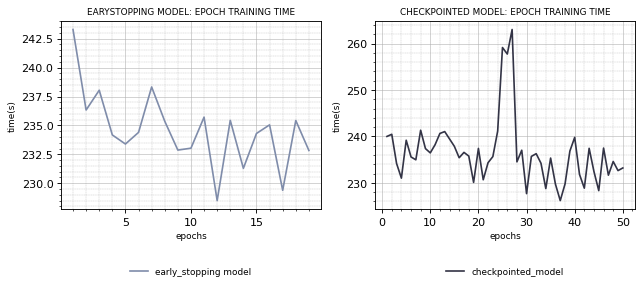

In [75]:
earlystop_epochs = np.arange(1, earlystop_stopped_epoch + 1)
checkpoint_epochs = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=80)
axes[0].plot(earlystop_epochs, earlystop_history.epoch_train_time,
             label="early_stopping model", color=PALETTES.wedding[10])

axes[0].set_title("EARYSTOPPING MODEL: EPOCH TRAINING TIME", fontsize=8)
axes[0].set_xlabel("epochs", fontsize=8)
axes[0].set_ylabel("time(s)", fontsize=8)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)
axes[0].legend(ncol=3, frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4), loc="lower center",)

axes[1].plot(checkpoint_epochs, checkpoint_history.epoch_train_time,
             label="checkpointed_model", color=PALETTES.wedding[11])

axes[1].set_title("CHECKPOINTED MODEL: EPOCH TRAINING TIME", fontsize=8)
axes[1].set_xlabel("epochs", fontsize=8)
axes[1].set_ylabel("time(s)", fontsize=8)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(ncol=3, frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4), loc="lower center")

plt.tight_layout()
plt.show()

### Training and Validation Accuracy

In this section, we visualize the **training** and **validation accuracy** of the two models across **$N$ epochs**:

* **Checkpointing Model (`checkpoint_model`)**
* **Early Stopping Model (`earlystop_model`)**

This comparison allows us to analyze the learning behavior of both training strategies and observe how each approach influences model performance over time.

By examining the accuracy curves, we can:

* Assess how quickly each model learns
* Identify signs of **overfitting or underfitting**
* Evaluate the impact of **early stopping** on training dynamics
* Compare overall generalization performance between the two models

This analysis provides insight into which training strategy leads to more stable and reliable performance for diabetic retinopathy classification.


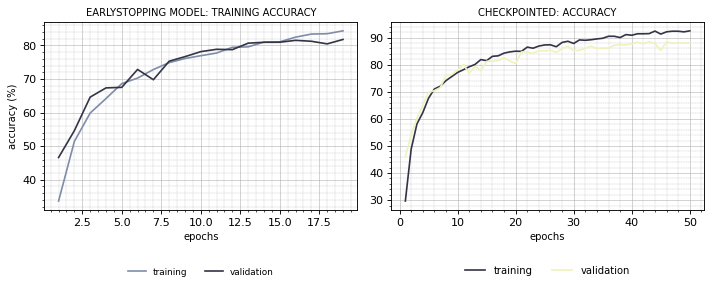

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=80)
axes[0].plot(earlystop_epochs,
             [i * 100 for i in earlystop_history.train_acc],
             label="training", color=PALETTES.wedding[10])
axes[0].plot(earlystop_epochs,
             [i * 100 for i in earlystop_history.val_acc],
             label="validation", color=PALETTES.wedding[11])

axes[0].set_title("EARLYSTOPPING MODEL: TRAINING ACCURACY", fontsize=9)
axes[0].set_xlabel("epochs", fontsize=9)
axes[0].set_ylabel("accuracy (%)", fontsize=9)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)

axes[0].legend(ncol=2, loc="lower center", frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4))


axes[1].plot(checkpoint_epochs,
             [i * 100 for i in checkpoint_history.train_acc],
             label="training", color=PALETTES.wedding[11])

axes[1].plot(checkpoint_epochs,
             [i * 100 for i in checkpoint_history.val_acc],
             label="validation", color=PALETTES.wedding[12])

axes[1].set_title("CHECKPOINTED: ACCURACY", fontsize=9)
axes[1].set_xlabel("epochs", fontsize=9)
axes[1].set_ylabel("", fontsize=9)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(loc="lower center",
               ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))
plt.tight_layout()
plt.show()

### Training and Validation Loss

In this section, we visualize the **training** and **validation loss** of the two models across **$N$ epochs**:

* **Checkpointing Model (`checkpoint_model`)**
* **Early Stopping Model (`earlystop_model`)**

This comparison provides insight into how each model learns over time and how effectively each training strategy minimizes error.

By analyzing the loss curves, we can:

* Observe the **convergence behavior** of each model
* Identify potential **overfitting** (e.g., decreasing training loss with increasing validation loss)
* Evaluate how **early stopping** influences training duration and stability
* Compare the effectiveness of each approach in achieving lower validation loss

This analysis is essential for understanding the generalization capability of the models and determining which training strategy yields more reliable performance for diabetic retinopathy classification.


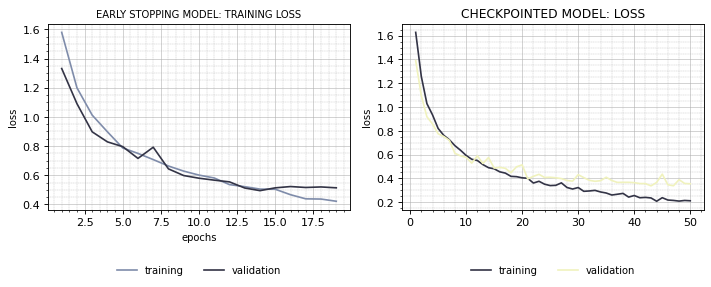

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=80)
axes[0].plot(earlystop_epochs,
             earlystop_history.train_losses,
             label="training", color=PALETTES.wedding[10])

axes[0].plot(earlystop_epochs,
             earlystop_history.val_losses,
             label="validation", color=PALETTES.wedding[11])

axes[0].set_title("EARLY STOPPING MODEL: TRAINING LOSS", fontsize=9)
axes[0].set_xlabel("epochs", fontsize=9)
axes[0].set_ylabel("loss", fontsize=9)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)

axes[0].legend(loc="lower center",  ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))

axes[1].plot(checkpoint_epochs,
             checkpoint_history.train_losses,
             label="training", color=PALETTES.wedding[11])

axes[1].plot(checkpoint_epochs,
             checkpoint_history.val_losses,
             label="validation", color=PALETTES.wedding[12])

axes[1].set_title("CHECKPOINTED MODEL: LOSS", fontsize=11)
axes[1].set_xlabel("", fontsize=9)
axes[1].set_ylabel("loss", fontsize=9)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(loc="lower center", ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()
plt.show()

### Model Evaluation on the Test Set

In this section, the **best checkpointed versions** of both models are evaluated using the **unseen test dataset**:

* **Checkpointing Model (`checkpoint_model`)**
* **Early Stopping Model (`earlystop_model`)**

For each model, the weights corresponding to the **lowest validation loss** (saved during training) are loaded and used for evaluation.

The **test loss** and **test accuracy** are computed to provide an unbiased estimate of each model’s ability to generalize to new, unseen data.

#### Purpose

This evaluation step is essential to:

* Assess the **true performance** of the models beyond the training and validation sets
* Compare the effectiveness of **checkpointing** and **early stopping** strategies
* Determine which approach yields better **generalization performance**

By using the test dataset only once for final evaluation, this process ensures a fair and reliable comparison between the two training strategies.


In [96]:
earlystop_model.load_state_dict(torch.load('earlystop_model.pt', weights_only=True))
checkpoint_model.load_state_dict(torch.load('checkpoint_model.pt', weights_only=True))

tabulate_data(
    ["NAME", "LOSS", "ACCURACY"],
    [
        ['checkpoint_model', *evaluate(checkpoint_model, test_iterator, criterions["checkpoint"], device)],
        ['earlystop_model', *evaluate(earlystop_model, test_iterator, criterions["earlystop"], device)],
    ], "BEST MODELS' LOSS AND ACCURACY"
)

BEST MODELS' LOSS AND ACCURACY
+------------------+--------------------+--------------------+
| NAME             |               LOSS |           ACCURACY |
+------------------+--------------------+--------------------+
| checkpoint_model | 0.3267857423052192 | 0.8860868569463491 |
| earlystop_model  | 0.5106663154438138 | 0.8121122475713491 |
+------------------+--------------------+--------------------+


### Model Evaluation Metrics

In this section, we evaluate the **best-performing model** using several standard metrics for multi-class classification. These metrics help provide a deeper understanding of the model's performance beyond overall accuracy.

The following evaluation methods will be used:

1. `Confusion Matrix`
2. `Classification Report`
3. `F1-score`
4. `Precision`
5. `Recall`

To compute these metrics, we first need to obtain the **true labels** and **predicted outputs** from the **test dataset**.

We will define a function called `get_predictions`, which takes the following parameters:

- `model`
- `iterator`
- `device`

This function will iterate over the **test iterator** and return the following values:

1. `images` - the input images from the test set  
2. `labels` - the true labels corresponding to the images  
3. `probs` - the predicted class probabilities produced by the model

In [79]:
def get_predictions(model, iterator, device):
  model.eval()
  images = []
  labels = []
  probs = []
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred, _ = model(x)
      y_prob = F.softmax(y_pred, 1).squeeze().detach()
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob)
  images = torch.cat(images, dim = 0)
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

### Generating Test Predictions

Next, we use the `get_predictions` function to retrieve the **images**, **labels**, and **predicted probabilities** from the `test_iterator` for further evaluation.

In [80]:
test_images_1, test_labels_1, probs_1 = get_predictions(earlystop_model, test_iterator, device)
test_images_2, test_labels_2, probs_2 = get_predictions(checkpoint_model, test_iterator, device)

In [81]:
preds_1 = torch.argmax(probs_1, 1)
preds_2 = torch.argmax(probs_2, 1)

### Visualizing Model Predictions

Now that we have obtained the **predicted labels** and **true labels** from the **test dataset**, we can visualize some sample predictions to qualitatively evaluate the model's performance during inference.

We define a function called `plot_prediction_images`, which plots selected test images along with their **predicted labels** and **ground truth labels**.

In [82]:
test_images_labels_1 = list(zip(test_images_1, preds_1, test_labels_1))
test_images_labels_2 = list(zip(test_images_2, preds_2, test_labels_2))

random.shuffle(test_images_labels_1)
random.shuffle(test_images_labels_2)


y_true_1 = []
y_pred_1 = []
y_true_2 = []
y_pred_2 = []
images_1 = []
images_2 = []

for img, pred, label in test_images_labels_1[:24]:
  y_true_1.append(label)
  y_pred_1.append(pred.cpu().item())
  images_1.append(img)

for img, pred, label in test_images_labels_2[:24]:
  y_true_2.append(label)
  y_pred_2.append(pred.cpu().item())
  images_2.append(img)


y_true_1 = np.array(y_true_1)
y_pred_1 = np.array(y_pred_1)
y_true_2 = np.array(y_true_2)
y_pred_2 = np.array(y_pred_2)


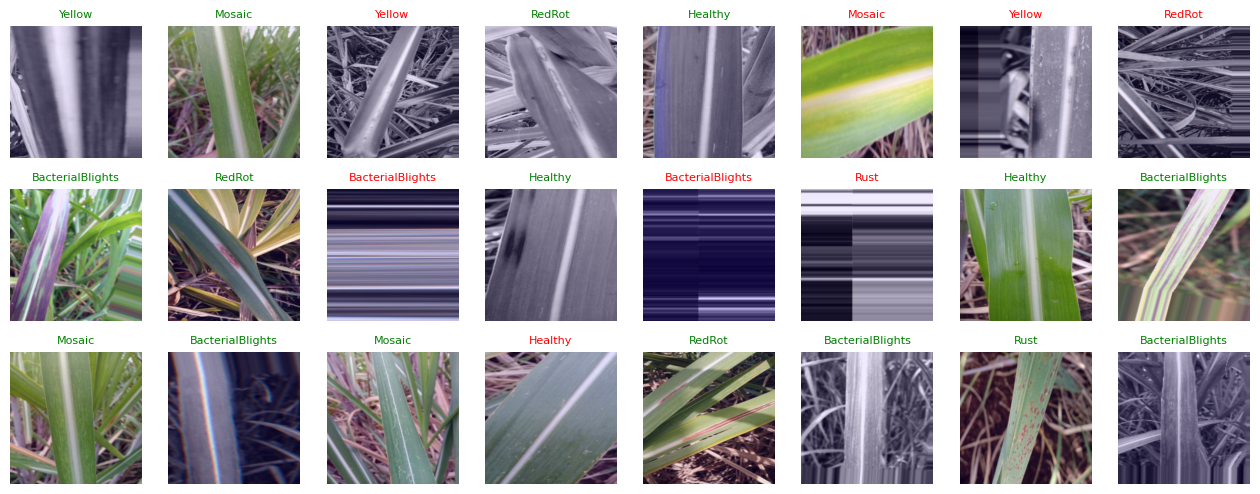

In [83]:
def plot_predictions_images(images_and_classes,
                            labels_true, labels_pred,
                            cols=5):
    rows = 3
    fig = plt.figure()
    fig.set_size_inches(cols * 2, rows * 2)
    for i, (image, label_true, label_pred) in enumerate(zip(images_and_classes, labels_true.astype("int32"), labels_pred)):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        image = normalize_image(image)
        plt.imshow(image.permute(1, 2, 0).cpu().numpy())
        plt.title(class_names[label_pred], color ='g' if label_true == label_pred else 'r', fontsize=8 )

plot_predictions_images(images_1[:24], y_true_1[:24], y_pred_1[:24], cols=8)

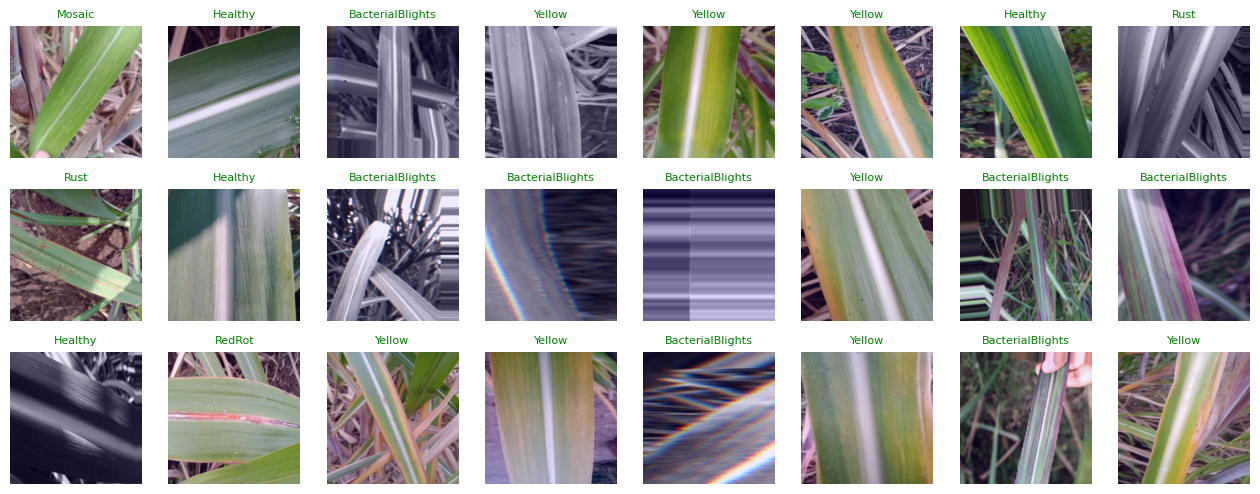

In [84]:
plot_predictions_images(images_2[:24], y_true_2[:24], y_pred_2[:24], cols=8)

### Interpreting the Prediction Visualization

From the visualization above, images with **green titles** represent **correctly classified** samples, while images with **red titles** represent **misclassified** samples. This color coding provides a quick visual indication of the model's performance during inference.

---

### Confusion Matrix

Next, we generate a **confusion matrix** to further evaluate how well the model performs on the **test dataset**. A confusion matrix provides a detailed summary of the model's predictions by comparing the **true labels** with the **predicted labels** for each class.

In the following code cell, we use the `plot_complicated_confusion_matrix` function from `helperfns.visualization`. This function takes the **true labels**, **predicted labels**, and **class names** as input and produces a visual representation of the model's classification performance across all classes.

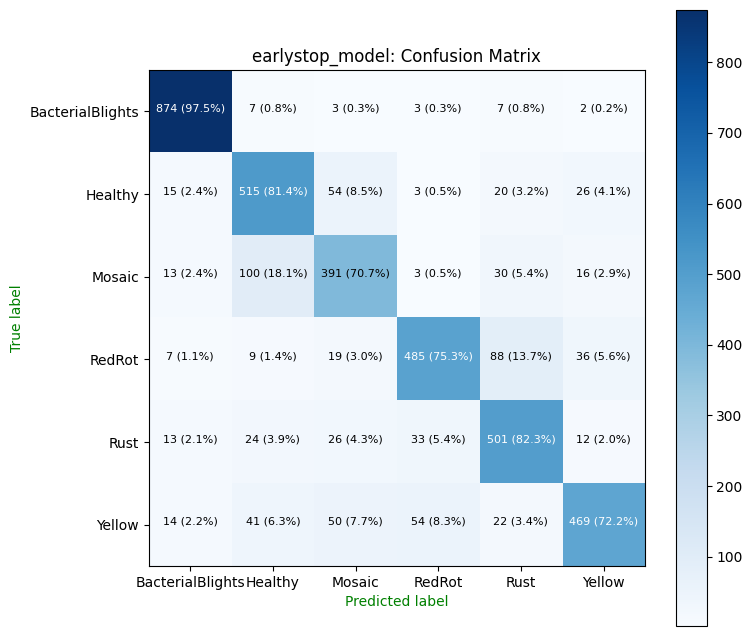

In [85]:
plot_complicated_confusion_matrix(test_labels_1, preds_1.cpu(), class_names,
                                  fontsize=8, figsize=(8, 8), title="earlystop_model: Confusion Matrix", 
                                )

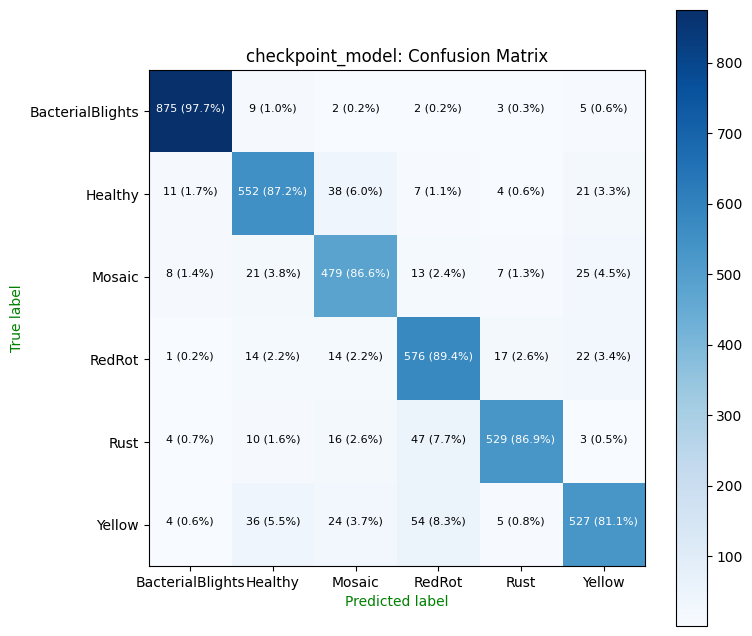

In [86]:
plot_complicated_confusion_matrix(test_labels_2, preds_2.cpu(), class_names,
                                  fontsize=8, figsize=(8, 8), title="checkpoint_model: Confusion Matrix")

### Classification Report

In the following code cell, we generate the **classification report** to assess the performance of each model on the **test dataset**. The report summarizes key evaluation metrics for each class, including **precision**, **recall**, and **F1-score**, providing a detailed view of the models' classification performance.

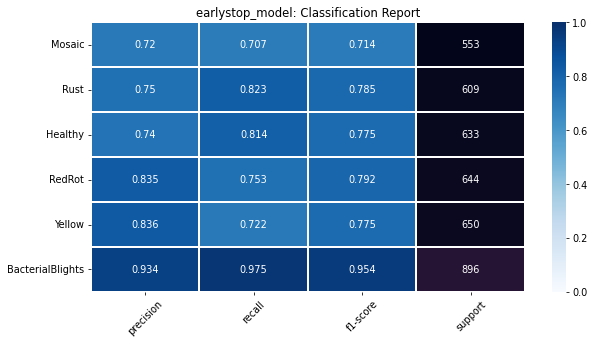

In [87]:
fig, ax = visualization.plot_classification_report(test_labels_1, preds_1.cpu(),
                    title='earlystop_model: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names)

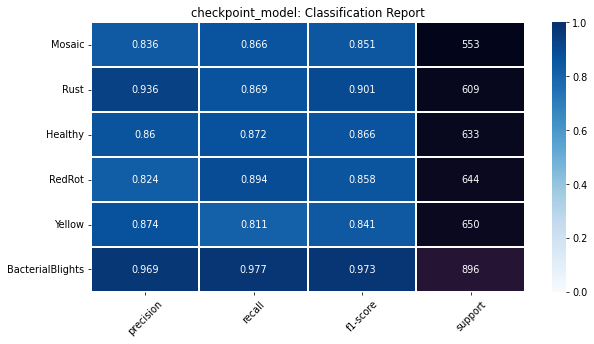

In [88]:
fig, ax = visualization.plot_classification_report(test_labels_2, preds_2.cpu(),
                    title='checkpoint_model: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = class_names)

### Incorrect Predictions

In this section, we analyze the **misclassified samples** from the test dataset. After collecting all predictions, we filter out the incorrect ones and sort them according to the model's **confidence in its incorrect predictions**.

Examining these cases helps identify patterns in the model's errors and provides insight into areas where the model may struggle during inference.

In [89]:
corrects_1 = torch.eq(test_labels_1, torch.from_numpy(preds_1.cpu().numpy()))
corrects_2 = torch.eq(test_labels_2, torch.from_numpy(preds_2.cpu().numpy()))

Getting incorrect predicted examples...

In [90]:
probabilities_1 = torch.tensor([float(probs_1[i][torch.argmax(probs_1[i])].detach().cpu().numpy()) for i in preds_1])
probabilities_2 = torch.tensor([float(probs_2[i][torch.argmax(probs_2[i])].detach().cpu().numpy()) for i in preds_2])

In [91]:
def get_incorrect_examples(images, labels, probabilities, corrects):
  incorrect_examples = []
  for image, label, prob, correct in zip(images, labels, probabilities, corrects):
    if not correct:
      incorrect_examples.append((image, label, prob))
  return incorrect_examples

incorrect_examples_1 = get_incorrect_examples(test_images_1, test_labels_1, probabilities_1, corrects_1)
incorrect_examples_2 = get_incorrect_examples(test_images_2, test_labels_2, probabilities_2, corrects_2)

incorrect_examples_1.sort(reverse = True, key = lambda x: torch.max(x[2], dim = 0).values)
incorrect_examples_2.sort(reverse = True, key = lambda x: torch.max(x[2], dim = 0).values)

We can then plot the most incorrectly predicted images along with the predicted class and the actual class.

In [92]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (6, 4))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = incorrect[i]
    image = image.permute(1, 2, 0)
    true_class = classes[true_label]
    incorrect_class = classes[0 if true_label == 1 else 1]
    if normalize:
      image = normalize_image(image)
    ax.imshow(image.cpu().numpy())
    ax.set_title(f'real: {true_class}\n' \
                  f'predicted: {incorrect_class}', fontsize=8)
    ax.axis('off')
  fig.subplots_adjust(hspace=0.4)

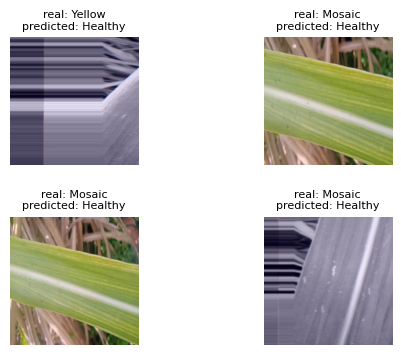

In [93]:
N_IMAGES = 8
plot_most_incorrect(incorrect_examples_1, class_names, N_IMAGES)

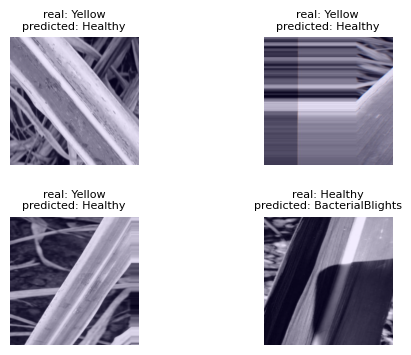

In [94]:
N_IMAGES = 8
plot_most_incorrect(incorrect_examples_2, class_names, N_IMAGES)